In [ ]:
!pip install -U scikit-learn

In [ ]:
import sklearn
print("scikit-learn version : ", sklearn.__version__)

scikit-learn version :  1.7.2


In [ ]:
!pip install kaggle

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle (1).json


{'kaggle (1).json': b'{"username":"barshneyochakraborty","key":"60d044f5392db81a389bbacbcbf9f240"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d fedesoriano/body-fat-prediction-dataset


Dataset URL: https://www.kaggle.com/datasets/fedesoriano/body-fat-prediction-dataset
License(s): copyright-authors
body-fat-prediction-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
import zipfile

with zipfile.ZipFile("body-fat-prediction-dataset.zip", "r") as zip_ref:
    zip_ref.extractall("bodyfat_data")

!ls bodyfat_data


bodyfat.csv


In [ ]:
import pandas as pd

df = pd.read_csv("bodyfat_data/bodyfat.csv")
df.head()


,Density,BodyFat,Age,Weight,Height,Neck,Chest,Abdomen,Hip,Thigh,Knee,Ankle,Biceps,Forearm,Wrist
0,1.0708,12.3,23,154.25,67.75,36.2,93.1,85.2,94.5,59.0,37.3,21.9,32.0,27.4,17.1
1,1.0853,6.1,22,173.25,72.25,38.5,93.6,83.0,98.7,58.7,37.3,23.4,30.5,28.9,18.2
2,1.0414,25.3,22,154.00,66.25,34.0,95.8,87.9,99.2,59.6,38.9,24.0,28.8,25.2,16.6
3,1.0751,10.4,26,184.75,72.25,37.4,101.8,86.4,101.2,60.1,37.3,22.8,32.4,29.4,18.2
4,1.0340,28.7,24,184.25,71.25,34.4,97.3,100.0,101.9,63.2,42.2,24.0,32.2,27.7,17.7


In [ ]:
# --- Import libraries ---
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# --- Drop missing values if any ---
df = df.dropna()

# --- Separate predictors (X) and target (y) ---
X = df.drop(columns=["BodyFat"])
y = df["BodyFat"]

# --- Split data: 70% train, 20% validation, 10% test ---
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=(1/3), random_state=42)

# --- Standardize ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# --- Train Linear Regression model ---
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# --- Validate and Test ---
y_val_pred = model.predict(X_val_scaled)
y_test_pred = model.predict(X_test_scaled)

print("\nValidation Performance:")
print(f"R² Score: {r2_score(y_val, y_val_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_val, y_val_pred)):.4f}")

print("\nTest Performance:")
print(f"R² Score: {r2_score(y_test, y_test_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_test_pred)):.4f}")

# --- Predict for a random test sample ---
rand_idx = np.random.randint(0, len(X_test))
sample = X_test.iloc[rand_idx:rand_idx+1]
sample_scaled = scaler.transform(sample)
pred = model.predict(sample_scaled)[0]

print("\nRandom Test Sample:")
print(sample)
print(f"\nPredicted Body Fat %: {pred:.2f}")
print(f"Actual Body Fat %: {y_test.iloc[rand_idx]:.2f}")




Validation Performance:
R² Score: 0.9862
RMSE: 0.8173

Test Performance:
R² Score: 0.9905
RMSE: 0.7379

Random Test Sample:
    Density  Age  Weight  Height  Neck  Chest  Abdomen   Hip  Thigh  Knee  \
66   1.0499   54   151.5   70.75  35.6   90.0     83.9  93.9   55.0  36.1   

    Ankle  Biceps  Forearm  Wrist  
66   21.7    29.6     27.4   17.4  

Predicted Body Fat %: 20.94
Actual Body Fat %: 21.50


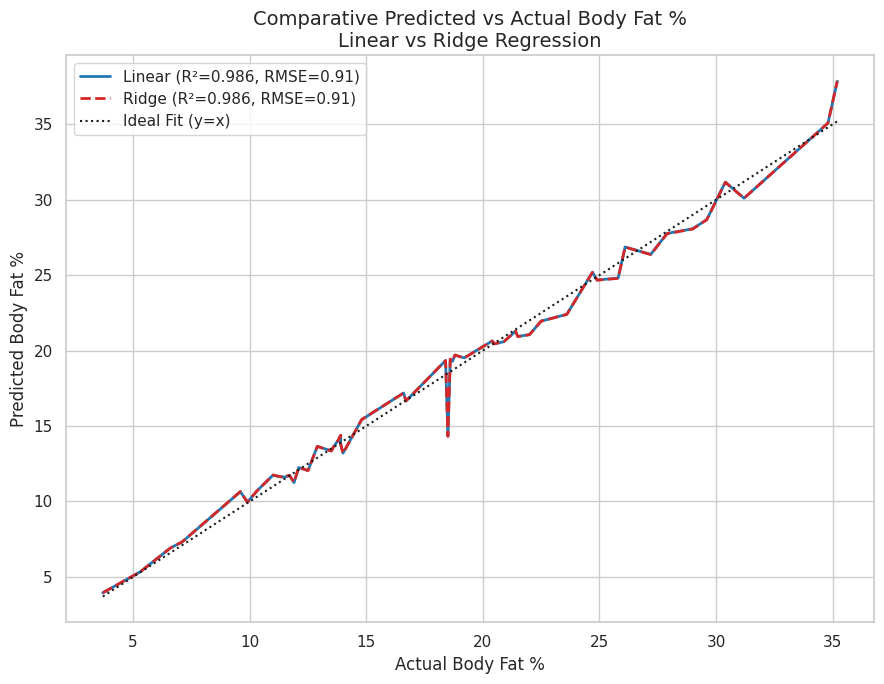

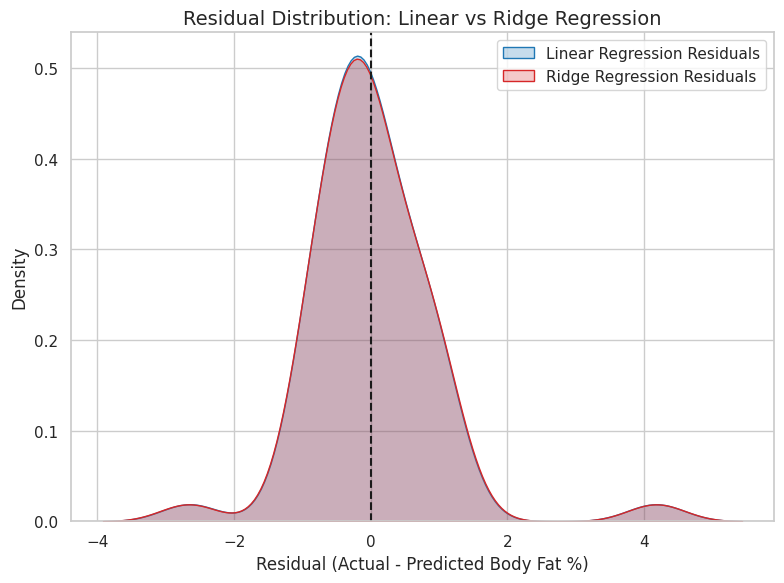

In [ ]:
# ==========================================
# Refined Comparative Visualization
# Linear vs Ridge Regression on Body Fat %
# ==========================================

!pip install kaggle seaborn

import zipfile, os, pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score

# --- Download Kaggle dataset ---
if not os.path.exists("body-fat-prediction-dataset.zip"):
    !kaggle datasets download -d fedesoriano/body-fat-prediction-dataset
    with zipfile.ZipFile("body-fat-prediction-dataset.zip", "r") as z:
        z.extractall("bodyfat_data")

# --- Load dataset ---
df = pd.read_csv("bodyfat_data/bodyfat.csv").dropna()

# --- Split ---
X = df.drop(columns=["BodyFat"])
y = df["BodyFat"]
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=(2/3), random_state=42)

# --- Scale ---
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)

# --- Train models ---
lin = LinearRegression().fit(X_train_s, y_train)
ridge = Ridge(alpha=0.1).fit(X_train_s, y_train)

# --- Predictions ---
y_pred_lin = lin.predict(X_test_s)
y_pred_ridge = ridge.predict(X_test_s)

# --- Compute metrics ---
r2_lin = r2_score(y_test, y_pred_lin)
r2_ridge = r2_score(y_test, y_pred_ridge)
rmse_lin = np.sqrt(mean_squared_error(y_test, y_pred_lin))
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))

# --- Sort for smooth plotting ---
sorted_idx = np.argsort(y_test)
y_sorted = np.array(y_test)[sorted_idx]
pred_lin_sorted = y_pred_lin[sorted_idx]
pred_ridge_sorted = y_pred_ridge[sorted_idx]

# --- Comparative Smooth Plot ---
plt.figure(figsize=(9,7))
sns.set(style="whitegrid")
plt.plot(y_sorted, pred_lin_sorted, color="#1f77b4", label=f"Linear (R²={r2_lin:.3f}, RMSE={rmse_lin:.2f})", linewidth=2)
plt.plot(y_sorted, pred_ridge_sorted, color="#d62728", linestyle="--", label=f"Ridge (R²={r2_ridge:.3f}, RMSE={rmse_ridge:.2f})", linewidth=2)
plt.plot([y_sorted.min(), y_sorted.max()], [y_sorted.min(), y_sorted.max()], 'k:', label="Ideal Fit (y=x)")
plt.title("Comparative Predicted vs Actual Body Fat %\nLinear vs Ridge Regression", fontsize=14)
plt.xlabel("Actual Body Fat %", fontsize=12)
plt.ylabel("Predicted Body Fat %", fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

# --- Residual Distribution Plot ---
res_lin = y_test - y_pred_lin
res_ridge = y_test - y_pred_ridge

plt.figure(figsize=(8,6))
sns.kdeplot(res_lin, color="#1f77b4", fill=True, label="Linear Regression Residuals")
sns.kdeplot(res_ridge, color="#d62728", fill=True, label="Ridge Regression Residuals")
plt.axvline(0, color='k', linestyle='--')
plt.title("Residual Distribution: Linear vs Ridge Regression", fontsize=14)
plt.xlabel("Residual (Actual - Predicted Body Fat %)")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# ============================================================
# JACKSON & POLLOCK (JP) 7-SITE BODY DENSITY FUNCTION (MEN)
# ============================================================

def jp7_body_density_men(
    chest_mm, midaxillary_mm, triceps_mm,
    subscapular_mm, abdomen_mm, suprailiac_mm,
    thigh_mm, age_years):

    S7 = (chest_mm + midaxillary_mm + triceps_mm +
          subscapular_mm + abdomen_mm + suprailiac_mm +
          thigh_mm)

    BD = (1.112
          - 0.00043499 * S7
          + 0.00000055 * (S7 ** 2)
          - 0.00028826 * age_years)

    return BD


# ============================================================
# JP–7 BD COLLECTION (BEFORE YOUR MAIN USER INPUT LOOP)
# ============================================================

print("\n====================================")
print("  BODY DENSITY (BD) ESTIMATION — JP7")
print("====================================")
print("For EACH data point, enter 7 skinfolds (in mm) + age.")
print("You will enter the 14 model features AFTER this step.\n")

n_bd = int(input("How many BD values do you want to compute? "))

BD_values = []

for i in range(n_bd):
    print(f"\n--- BD Calculation for Data Point {i+1} ---")

    chest = float(input("Chest skinfold (mm): "))
    midax = float(input("Midaxillary skinfold (mm): "))
    triceps = float(input("Triceps skinfold (mm): "))
    subscap = float(input("Subscapular skinfold (mm): "))
    abdomen_sf = float(input("Abdomen skinfold (mm): "))
    suprailiac = float(input("Suprailiac skinfold (mm): "))
    thigh = float(input("Thigh skinfold (mm): "))
    age_years = float(input("Age (years): "))

    BD = jp7_body_density_men(
        chest, midax, triceps,
        subscap, abdomen_sf, suprailiac,
        thigh, age_years
    )

    BD_values.append(BD)
    print(f">>> Body Density for Data Point {i+1}: {BD:.5f} g/cm³")
    print("Use this BD value as your 'Density' feature.\n")



  BODY DENSITY (BD) ESTIMATION — JP7
For EACH data point, enter 7 skinfolds (in mm) + age.
You will enter the 14 model features AFTER this step.



KeyboardInterrupt: Interrupted by user

In [ ]:
# ============================================================
# BODY FAT PREDICTION WITH USER INPUT (Linear & Ridge)
# ============================================================

!pip install kaggle seaborn

import zipfile, os, pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import r2_score, mean_squared_error

# --- Download Dataset from Kaggle ---
if not os.path.exists("body-fat-prediction-dataset.zip"):
    !kaggle datasets download -d fedesoriano/body-fat-prediction-dataset
    with zipfile.ZipFile("body-fat-prediction-dataset.zip", "r") as z:
        z.extractall("bodyfat_data")

# --- Load dataset ---
df = pd.read_csv("bodyfat_data/bodyfat.csv").dropna()

# --- Separate predictors and target ---
X = df.drop(columns=["BodyFat"])
y = df["BodyFat"]

# --- Train/Val/Test Split ---
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=(1/3), random_state=42)

# --- Standardize ---
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)

# --- Train Models ---
lin = LinearRegression().fit(X_train_s, y_train)
ridge = Ridge(alpha=0.1).fit(X_train_s, y_train)

# ============================================================
# USER INPUT PREDICTION SECTION
# ============================================================

feature_names = list(X.columns)

print("\nAvailable Features for Prediction:")
for i, f in enumerate(feature_names, start=1):
    print(f"{i}. {f}")

# Number of samples to enter
n = int(input("\nHow many data points do you want to enter? "))

user_data = []

print("\nEnter the following 14 features for each data point:\n")

for i in range(n):
    print(f"\n--- Data Point {i+1} ---")
    row = []
    for f in feature_names:
        val = float(input(f"Enter value for {f}: "))
        row.append(val)
    user_data.append(row)

# Convert to DataFrame
user_df = pd.DataFrame(user_data, columns=feature_names)

# Scale using the SAME TRAINED SCALER
user_scaled = scaler.transform(user_df)

# Predictions
pred_lin = lin.predict(user_scaled)
pred_ridge = ridge.predict(user_scaled)

# Print final predictions
print("\n==============================================")
print("           PREDICTED BODY FAT (%)             ")
print("==============================================")

for i in range(n):
    print(f"\nData Point {i+1}:")
    print(f"  Linear Regression Prediction : {pred_lin[i]:.2f} %")
    print(f"  Ridge Regression Prediction  : {pred_ridge[i]:.2f} %")

print("\nPrediction Completed Successfully.")



Available Features for Prediction:
1. Density
2. Age
3. Weight
4. Height
5. Neck
6. Chest
7. Abdomen
8. Hip
9. Thigh
10. Knee
11. Ankle
12. Biceps
13. Forearm
14. Wrist

How many data points do you want to enter? 1

Enter the following 14 features for each data point:


--- Data Point 1 ---
Enter value for Density: 1.06089
Enter value for Age: 25
Enter value for Weight: 246
Enter value for Height: 179
Enter value for Neck: 46
Enter value for Chest: 120
Enter value for Abdomen: 105
Enter value for Hip: 120
Enter value for Thigh: 95
Enter value for Knee: 36
Enter value for Ankle: 24
Enter value for Biceps: 45
Enter value for Forearm: 39.89
Enter value for Wrist: 19.22

           PREDICTED BODY FAT (%)             

Data Point 1:
  Linear Regression Prediction : 15.48 %
  Ridge Regression Prediction  : 15.52 %

Prediction Completed Successfully.


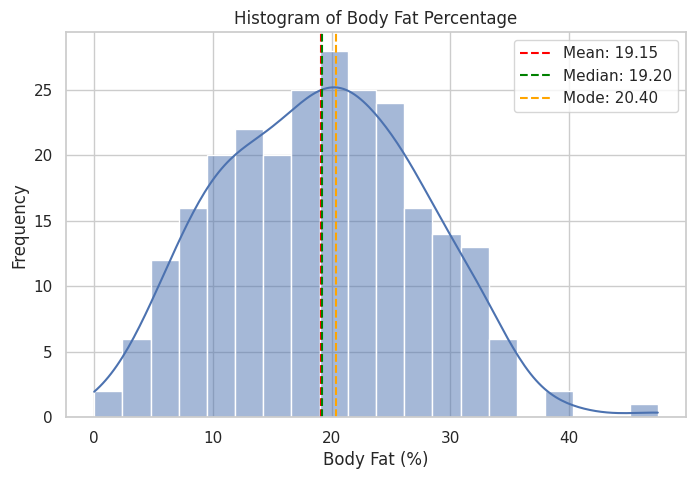

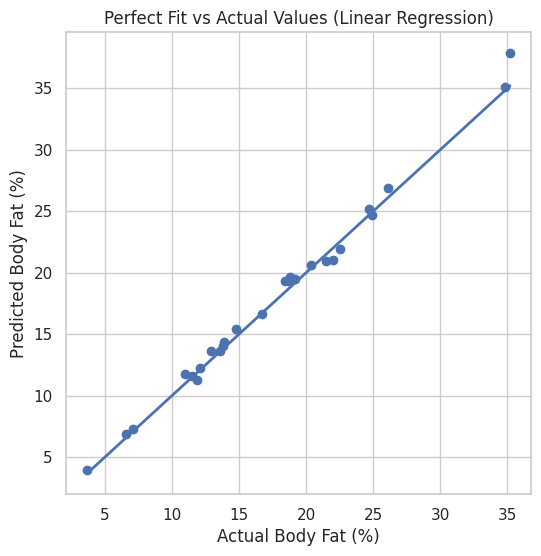

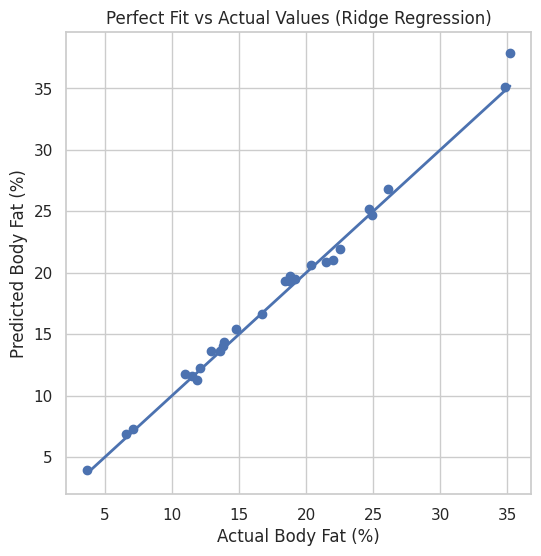

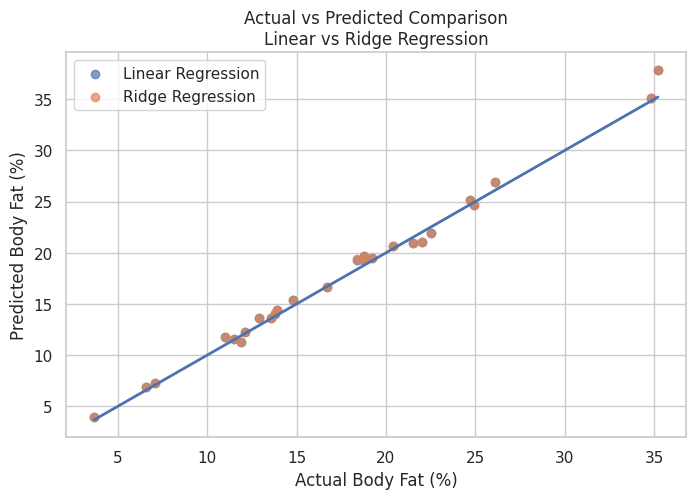

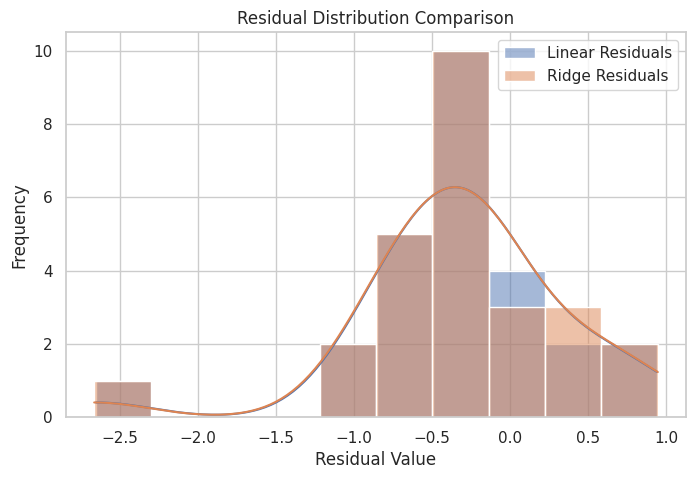

In [ ]:
# ============================================================
# Generate Predictions SPECIFICALLY for Test Set
# ============================================================

test_pred_lin = lin.predict(X_test_s)
test_pred_ridge = ridge.predict(X_test_s)

# ============================================================
# 1. Histogram of Body Fat % with Mean, Median, Mode
# ============================================================

plt.figure(figsize=(8,5))
sns.histplot(df["BodyFat"], kde=True, bins=20)
plt.axvline(df["BodyFat"].mean(), color='red', linestyle='--', label=f"Mean: {df['BodyFat'].mean():.2f}")
plt.axvline(df["BodyFat"].median(), color='green', linestyle='--', label=f"Median: {df['BodyFat'].median():.2f}")
plt.axvline(df["BodyFat"].mode()[0], color='orange', linestyle='--', label=f"Mode: {df['BodyFat'].mode()[0]:.2f}")
plt.title("Histogram of Body Fat Percentage")
plt.xlabel("Body Fat (%)")
plt.ylabel("Frequency")
plt.legend()
plt.show()

# ============================================================
# 2. Perfect Fit vs Actual - Linear Regression
# ============================================================

plt.figure(figsize=(6,6))
plt.scatter(y_test, test_pred_lin)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], linewidth=2)
plt.title("Perfect Fit vs Actual Values (Linear Regression)")
plt.xlabel("Actual Body Fat (%)")
plt.ylabel("Predicted Body Fat (%)")
plt.show()

# ============================================================
# 3. Perfect Fit vs Actual - Ridge Regression
# ============================================================

plt.figure(figsize=(6,6))
plt.scatter(y_test, test_pred_ridge)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], linewidth=2)
plt.title("Perfect Fit vs Actual Values (Ridge Regression)")
plt.xlabel("Actual Body Fat (%)")
plt.ylabel("Predicted Body Fat (%)")
plt.show()

# ============================================================
# 4. Linear vs Ridge - Comparative Plot
# ============================================================

plt.figure(figsize=(8,5))
plt.scatter(y_test, test_pred_lin, label="Linear Regression", alpha=0.7)
plt.scatter(y_test, test_pred_ridge, label="Ridge Regression", alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], linewidth=2)
plt.title("Actual vs Predicted Comparison\nLinear vs Ridge Regression")
plt.xlabel("Actual Body Fat (%)")
plt.ylabel("Predicted Body Fat (%)")
plt.legend()
plt.show()

# ============================================================
# 5. Residual Distribution Plot
# ============================================================

residuals_lin = y_test - test_pred_lin
residuals_ridge = y_test - test_pred_ridge

plt.figure(figsize=(8,5))
sns.histplot(residuals_lin, kde=True, label="Linear Residuals", alpha=0.5)
sns.histplot(residuals_ridge, kde=True, label="Ridge Residuals", alpha=0.5)
plt.title("Residual Distribution Comparison")
plt.xlabel("Residual Value")
plt.ylabel("Frequency")
plt.legend()
plt.show()

